
# MELLITUS.IA — Treinamento do Modelo de Previsão de Risco de Diabetes Tipo 2
# SENAC Pernambuco 2026.1 — Inteligência Artificial | Prof. Rodrigo Rios
#

# ║  CÉLULA 1 — Instalação de dependências

In [1]:
!pip install -q ucimlrepo scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib shap

# ║  CÉLULA 2 — Importações

In [2]:
import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


# ║  CÉLULA 3 — Carregamento do dataset CDC BRFSS  

In [3]:
print(" Baixando dataset CDC BRFSS (pode levar alguns segundos)...")
dataset = fetch_ucirepo(id=891)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

# A variável alvo original tem 3 classes: 0 = saudável, 1 = pré-diabetes, 2 = diabetes
# Vamos binarizar: 0 = sem diabetes | 1 = pré-diabetes ou diabetes
# Isso é mais útil clinicamente — queremos detectar QUALQUER risco
y_raw.columns = ["target_original"]
y_binary = (y_raw["target_original"] >= 1).astype(int).rename("diabetes")

df = X_raw.copy()
df["diabetes"] = y_binary.values

print("=" * 60)
print("  MELLITUS.IA — CDC BRFSS Dataset carregado!")
print("=" * 60)
print(f"\n  Registros totais : {len(df):,}")
print(f"  Variáveis        : {len(df.columns) - 1}")
print(f"\n  Distribuição da variável alvo:")
dist = df["diabetes"].value_counts()
print(f"    Sem diabetes  (0): {dist[0]:,} ({dist[0]/len(df)*100:.1f}%)")
print(f"    Com diabetes  (1): {dist[1]:,} ({dist[1]/len(df)*100:.1f}%)")
print("=" * 60)

df.head(5)

 Baixando dataset CDC BRFSS (pode levar alguns segundos)...
  MELLITUS.IA — CDC BRFSS Dataset carregado!

  Registros totais : 253,680
  Variáveis        : 21

  Distribuição da variável alvo:
    Sem diabetes  (0): 218,334 (86.1%)
    Com diabetes  (1): 35,346 (13.9%)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


# ║  CÉLULA 4 — Dicionário das variáveis       

In [4]:
# Mapeamento das colunas originais para nomes legíveis em português
MAPA_COLUNAS = {
    "HighBP":           "pressao_alta",          # Hipertensão (0/1)
    "HighChol":         "colesterol_alto",        # Colesterol alto (0/1)
    "CholCheck":        "check_colesterol",       # Fez check de colesterol nos últimos 5 anos (0/1)
    "BMI":              "imc",                    # Índice de Massa Corporal
    "Smoker":           "fumante",                # Fumou +100 cigarros na vida (0/1)
    "Stroke":           "avc",                    # Já teve AVC (0/1)
    "HeartDiseaseorAttack": "doenca_cardiaca",   # Doença coronária ou infarto (0/1)
    "PhysActivity":     "atividade_fisica",       # Atividade física nos últimos 30 dias (0/1)
    "Fruits":           "consome_frutas",         # Consome frutas 1+ vez/dia (0/1)
    "Veggies":          "consome_verduras",       # Consome verduras 1+ vez/dia (0/1)
    "HvyAlcoholConsump":"alcool_excessivo",       # Consumo excessivo de álcool (0/1)
    "AnyHealthcare":    "tem_plano_saude",        # Tem plano de saúde (0/1)
    "NoDocbcCost":      "sem_medico_por_custo",   # Deixou de ir ao médico por custo (0/1)
    "GenHlth":          "saude_geral",            # Saúde geral (1=excelente a 5=ruim)
    "MentHlth":         "saude_mental_dias",      # Dias com saúde mental ruim (0-30)
    "PhysHlth":         "saude_fisica_dias",      # Dias com saúde física ruim (0-30)
    "DiffWalk":         "dificuldade_caminhar",   # Dificuldade de caminhar (0/1)
    "Sex":              "sexo",                   # Sexo (0=feminino, 1=masculino)
    "Age":              "faixa_etaria",           # Faixa etária (1=18-24 até 13=80+)
    "Education":        "escolaridade",           # Nível de escolaridade (1-6)
    "Income":           "renda",                  # Faixa de renda (1-8)
}

df.rename(columns=MAPA_COLUNAS, inplace=True)

print("Colunas renomeadas para português:")
for orig, pt in MAPA_COLUNAS.items():
    print(f"  {orig:28s} → {pt}")

Colunas renomeadas para português:
  HighBP                       → pressao_alta
  HighChol                     → colesterol_alto
  CholCheck                    → check_colesterol
  BMI                          → imc
  Smoker                       → fumante
  Stroke                       → avc
  HeartDiseaseorAttack         → doenca_cardiaca
  PhysActivity                 → atividade_fisica
  Fruits                       → consome_frutas
  Veggies                      → consome_verduras
  HvyAlcoholConsump            → alcool_excessivo
  AnyHealthcare                → tem_plano_saude
  NoDocbcCost                  → sem_medico_por_custo
  GenHlth                      → saude_geral
  MentHlth                     → saude_mental_dias
  PhysHlth                     → saude_fisica_dias
  DiffWalk                     → dificuldade_caminhar
  Sex                          → sexo
  Age                          → faixa_etaria
  Education                    → escolaridade
  Income                

# ║  CÉLULA 5 — Análise exploratória: prevalência por grupo  

KeyboardInterrupt: 

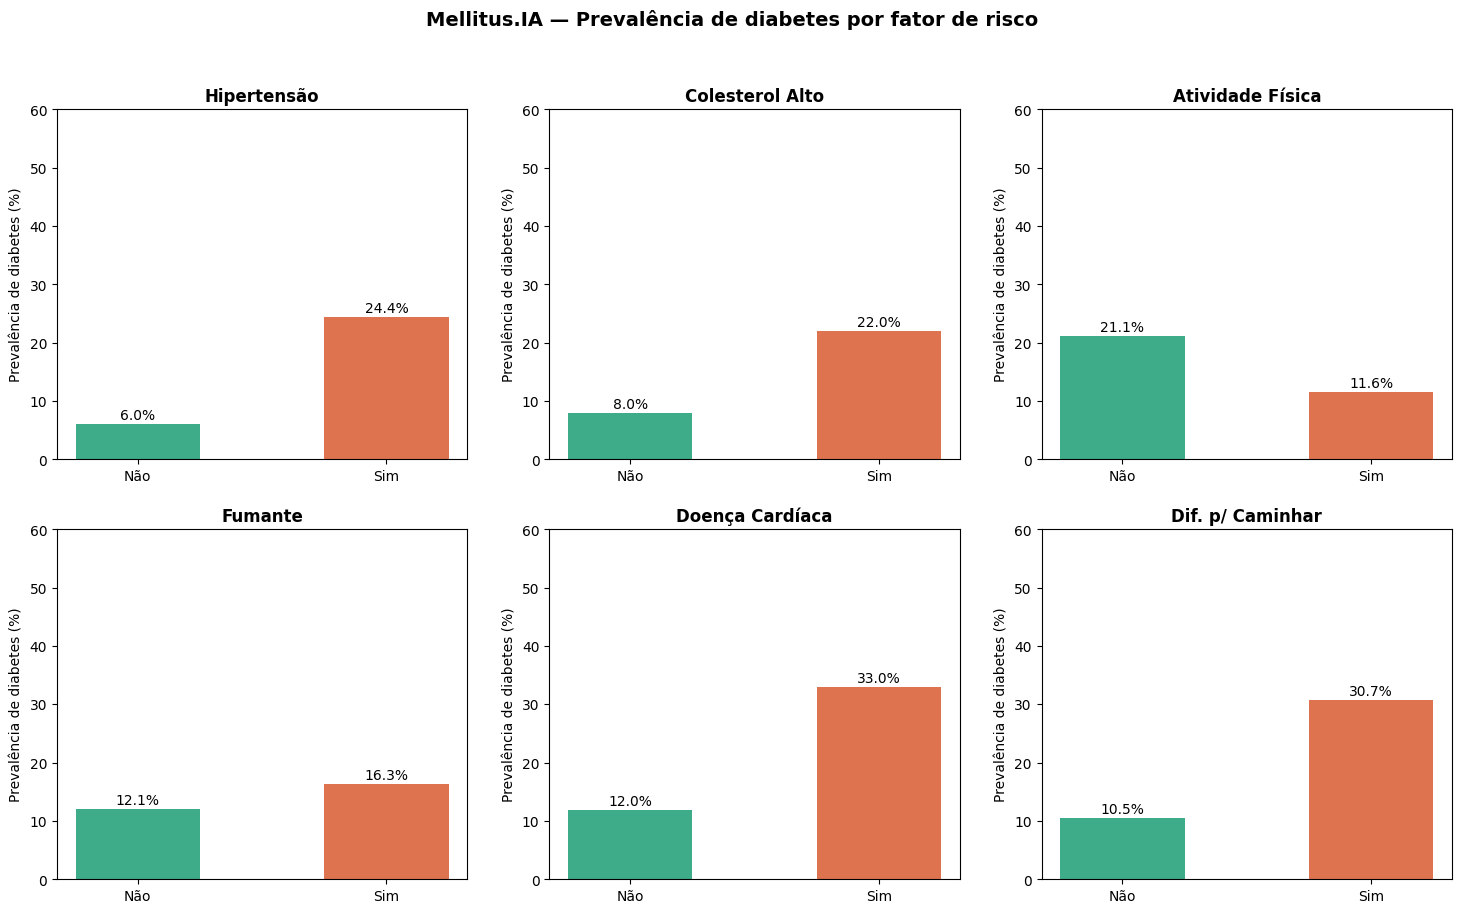

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Mellitus.IA — Prevalência de diabetes por fator de risco", fontsize=14, fontweight="bold")

COR_SEM  = "#1D9E75"
COR_COM  = "#D85A30"

grupos = [
    ("pressao_alta",       "Hipertensão",        {0: "Não", 1: "Sim"}),
    ("colesterol_alto",    "Colesterol Alto",     {0: "Não", 1: "Sim"}),
    ("atividade_fisica",   "Atividade Física",    {0: "Não", 1: "Sim"}),
    ("fumante",            "Fumante",             {0: "Não", 1: "Sim"}),
    ("doenca_cardiaca",    "Doença Cardíaca",     {0: "Não", 1: "Sim"}),
    ("dificuldade_caminhar","Dif. p/ Caminhar",  {0: "Não", 1: "Sim"}),
]

for ax, (col, titulo, labels) in zip(axes.flat, grupos):
    prev = df.groupby(col)["diabetes"].mean() * 100
    bars = ax.bar(
        [labels.get(k, str(k)) for k in prev.index],
        prev.values,
        color=[COR_SEM, COR_COM],
        width=0.5, alpha=0.85
    )
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_ylabel("Prevalência de diabetes (%)")
    ax.set_ylim(0, 60)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{bar.get_height():.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("prevalencia_por_fator.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Gráfico salvo: prevalencia_por_fator.png")

# ║  CÉLULA 6 — Análise exploratória: IMC e faixa etária

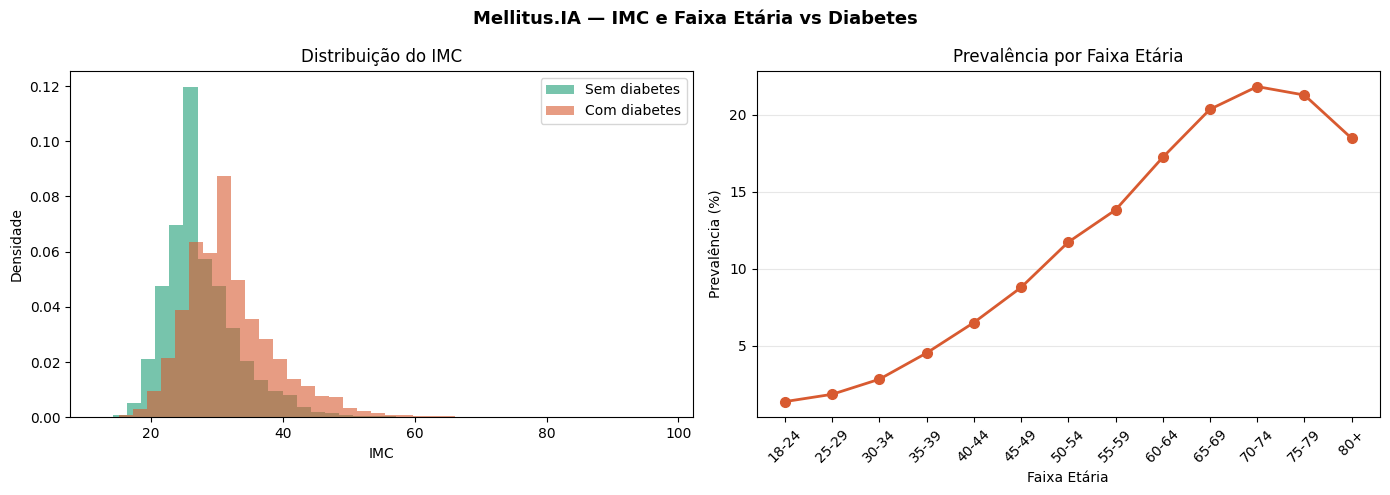

📊 Gráfico salvo: imc_e_idade.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mellitus.IA — IMC e Faixa Etária vs Diabetes", fontsize=13, fontweight="bold")

# IMC por classe
for label, cor, nome in [(0, COR_SEM, "Sem diabetes"), (1, COR_COM, "Com diabetes")]:
    axes[0].hist(df[df["diabetes"] == label]["imc"], bins=40,
                 alpha=0.6, color=cor, label=nome, density=True)
axes[0].set_title("Distribuição do IMC")
axes[0].set_xlabel("IMC")
axes[0].set_ylabel("Densidade")
axes[0].legend()

# Prevalência por faixa etária
FAIXAS = {
    1:"18-24", 2:"25-29", 3:"30-34", 4:"35-39", 5:"40-44",
    6:"45-49", 7:"50-54", 8:"55-59", 9:"60-64", 10:"65-69",
    11:"70-74", 12:"75-79", 13:"80+"
}
prev_idade = df.groupby("faixa_etaria")["diabetes"].mean() * 100
axes[1].plot(
    [FAIXAS.get(k, str(k)) for k in prev_idade.index],
    prev_idade.values, "o-", color=COR_COM, lw=2, ms=7
)
axes[1].set_title("Prevalência por Faixa Etária")
axes[1].set_xlabel("Faixa Etária")
axes[1].set_ylabel("Prevalência (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("imc_e_idade.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Gráfico salvo: imc_e_idade.png")

# ║  CÉLULA 7 — Verificação de qualidade dos dados

In [7]:
print("Valores nulos por coluna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Nenhum valor nulo! ✅")

print(f"\nEstatísticas descritivas do IMC:")
print(df["imc"].describe().round(2))

print(f"\nIMC inválido (< 10 ou > 70): {((df['imc'] < 10) | (df['imc'] > 70)).sum()} registros")

# Remover IMC claramente inválido
df = df[(df["imc"] >= 10) & (df["imc"] <= 70)].copy()
print(f"Dataset após limpeza: {len(df):,} registros")

Valores nulos por coluna:
  Nenhum valor nulo! ✅

Estatísticas descritivas do IMC:
count    253680.00
mean         28.38
std           6.61
min          12.00
25%          24.00
50%          27.00
75%          31.00
max          98.00
Name: imc, dtype: float64

IMC inválido (< 10 ou > 70): 584 registros
Dataset após limpeza: 253,096 registros


# ║  CÉLULA 8 — Seleção de features e engenharia

In [8]:
FEATURES_BASE = [
    "imc",
    "pressao_alta",
    "colesterol_alto",
    "atividade_fisica",
    "saude_geral",
    "faixa_etaria",
    "doenca_cardiaca",
    "avc",
    "fumante",
    "dificuldade_caminhar",
    "sexo",
    "saude_fisica_dias",
    "saude_mental_dias",
    "consome_frutas",
    "consome_verduras",
    "alcool_excessivo",
    "escolaridade",
    "renda",
]

X = df[FEATURES_BASE].copy()
y = df["diabetes"].copy()

# ── Engenharia de features ──────────────────────────────────────

# Risco combinado: hipertensão + colesterol + doença cardíaca
X["risco_cardiovascular"] = (
    df["pressao_alta"] + df["colesterol_alto"] + df["doenca_cardiaca"]
)

# Categoria de IMC (OMS)
X["categoria_imc"] = pd.cut(
    X["imc"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# Estilo de vida saudável (score 0-3)
X["estilo_vida_saudavel"] = (
    df["atividade_fisica"] +
    df["consome_frutas"] +
    df["consome_verduras"]
)

# Faixa etária × IMC (interação)
X["idade_x_imc"] = X["faixa_etaria"] * X["imc"]

# Saúde geral ruim (binário: 4 ou 5 = ruim/muito ruim)
X["saude_ruim"] = (X["saude_geral"] >= 4).astype(int)

FEATURE_NAMES = list(X.columns)

print(f"Total de features após engenharia: {len(FEATURE_NAMES)}")
print("Features:", FEATURE_NAMES)

Total de features após engenharia: 23
Features: ['imc', 'pressao_alta', 'colesterol_alto', 'atividade_fisica', 'saude_geral', 'faixa_etaria', 'doenca_cardiaca', 'avc', 'fumante', 'dificuldade_caminhar', 'sexo', 'saude_fisica_dias', 'saude_mental_dias', 'consome_frutas', 'consome_verduras', 'alcool_excessivo', 'escolaridade', 'renda', 'risco_cardiovascular', 'categoria_imc', 'estilo_vida_saudavel', 'idade_x_imc', 'saude_ruim']


# ║  CÉLULA 9 — Split treino/teste e balanceamento   

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"\nDesbalanceamento no treino:")
vc = y_train.value_counts()
print(f"  Sem diabetes : {vc[0]:,} ({vc[0]/len(y_train)*100:.1f}%)")
print(f"  Com diabetes : {vc[1]:,} ({vc[1]/len(y_train)*100:.1f}%)")

# SMOTE para balancear as classes no treino
smote = SMOTE(random_state=42, sampling_strategy=0.6)  # não precisa ser 50/50 exato
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nApós SMOTE:")
vc2 = pd.Series(y_train_bal).value_counts()
print(f"  Sem diabetes : {vc2[0]:,}")
print(f"  Com diabetes : {vc2[1]:,}")


Treino: 202,476 | Teste: 50,620

Desbalanceamento no treino:
  Sem diabetes : 174,260 (86.1%)
  Com diabetes : 28,216 (13.9%)

Após SMOTE:
  Sem diabetes : 174,260
  Com diabetes : 104,556


# ║  CÉLULA 10 — Comparação de modelos com validação cruzada

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=5, random_state=42
        ))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=6,
            scale_pos_weight=2,
            use_label_encoder=False, eval_metric="logloss",
            random_state=42, n_jobs=-1
        ))
    ]),
}

print("Comparando modelos (validação cruzada 5 folds)...\n")
resultados = {}

for nome, pipeline in candidatos.items():
    scores_acc = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="accuracy")
    scores_roc = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="roc_auc")
    scores_rec = cross_val_score(pipeline, X_train_bal, y_train_bal, cv=cv, scoring="recall")
    resultados[nome] = {
        "Acurácia": scores_acc.mean(),
        "ROC-AUC":  scores_roc.mean(),
        "Recall":   scores_rec.mean(),
    }
    print(f"  {nome:25s} → Acurácia: {scores_acc.mean():.3f} | ROC-AUC: {scores_roc.mean():.3f} | Recall: {scores_rec.mean():.3f}")

melhor_nome = max(resultados, key=lambda k: resultados[k]["ROC-AUC"])
print(f"\n🏆 Melhor modelo (ROC-AUC): {melhor_nome}")

Comparando modelos (validação cruzada 5 folds)...

  Regressão Logística       → Acurácia: 0.771 | ROC-AUC: 0.858 | Recall: 0.753
  Random Forest             → Acurácia: 0.754 | ROC-AUC: 0.845 | Recall: 0.809
  Gradient Boosting         → Acurácia: 0.791 | ROC-AUC: 0.871 | Recall: 0.676
  XGBoost                   → Acurácia: 0.766 | ROC-AUC: 0.874 | Recall: 0.841

🏆 Melhor modelo (ROC-AUC): XGBoost


# ║  CÉLULA 11 — Treino final e avaliação no conjunto de teste

In [11]:
modelo_final = candidatos[melhor_nome]
modelo_final.fit(X_train_bal, y_train_bal)

y_pred      = modelo_final.predict(X_test)
y_pred_prob = modelo_final.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
f1      = f1_score(y_test, y_pred)
recall  = recall_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)

print("=" * 60)
print(f"  RESULTADOS FINAIS — {melhor_nome}")
print("=" * 60)
print(f"  Acurácia   : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  ROC-AUC    : {roc_auc:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  Recall     : {recall:.4f}  ← minimizar falsos negativos")
print(f"  Precisão   : {prec:.4f}")
print("=" * 60)
print("\nRelatório detalhado:")
print(classification_report(y_test, y_pred, target_names=["Sem diabetes", "Com diabetes"]))

  RESULTADOS FINAIS — XGBoost
  Acurácia   : 0.7195  (72.0%)
  ROC-AUC    : 0.7967
  F1-Score   : 0.4198
  Recall     : 0.7282  ← minimizar falsos negativos
  Precisão   : 0.2949

Relatório detalhado:
              precision    recall  f1-score   support

Sem diabetes       0.94      0.72      0.82     43566
Com diabetes       0.29      0.73      0.42      7054

    accuracy                           0.72     50620
   macro avg       0.62      0.72      0.62     50620
weighted avg       0.85      0.72      0.76     50620



# ║  CÉLULA 12 — Visualizações de avaliação     

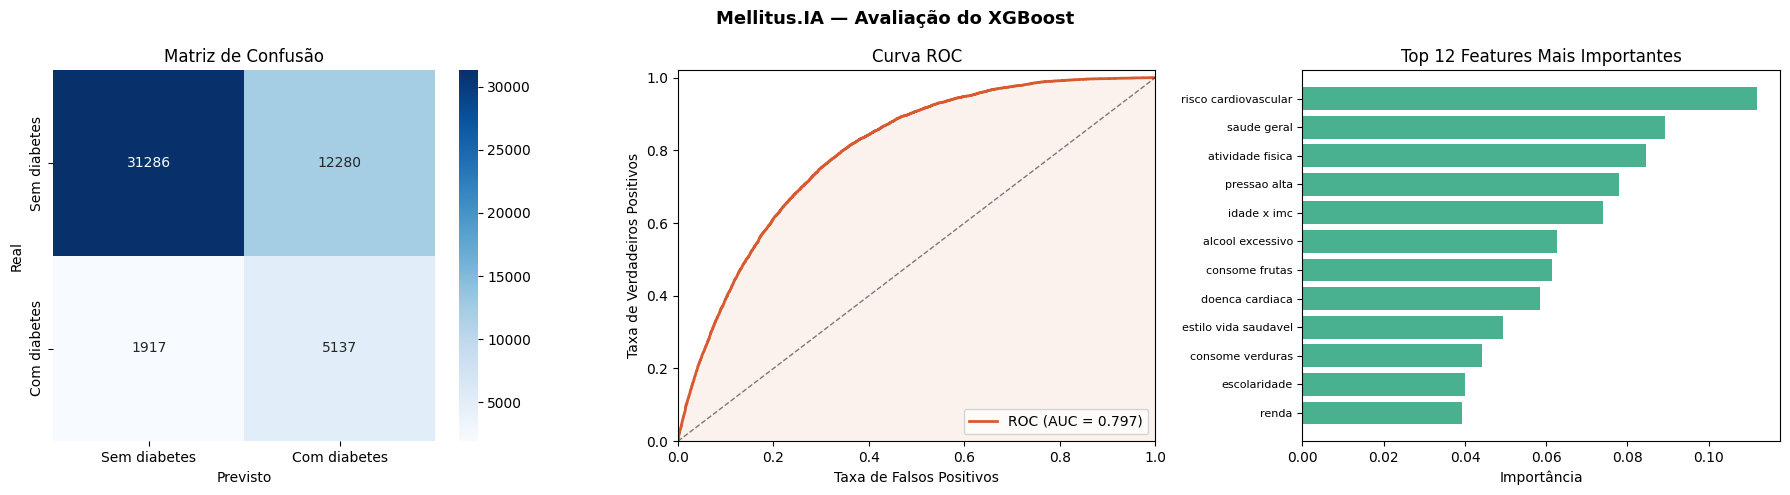

📊 Gráfico salvo: avaliacao_modelo.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Mellitus.IA — Avaliação do {melhor_nome}", fontsize=13, fontweight="bold")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Sem diabetes", "Com diabetes"],
    yticklabels=["Sem diabetes", "Com diabetes"]
)
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Previsto")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#D85A30", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#D85A30")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

# Importância das Features
try:
    importancias = modelo_final.named_steps["model"].feature_importances_
    indices = np.argsort(importancias)[::-1][:12]
    nomes_feat = [FEATURE_NAMES[i].replace("_", " ") for i in indices]
    axes[2].barh(range(len(indices)), importancias[indices][::-1], color="#1D9E75", alpha=0.8)
    axes[2].set_yticks(range(len(indices)))
    axes[2].set_yticklabels(nomes_feat[::-1], fontsize=8)
    axes[2].set_title("Top 12 Features Mais Importantes")
    axes[2].set_xlabel("Importância")
except AttributeError:
    axes[2].text(0.5, 0.5, "Importância não\ndisponível", ha="center", va="center",
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig("avaliacao_modelo.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Gráfico salvo: avaliacao_modelo.png")


# ║  CÉLULA 13 — Análise SHAP (explicabilidade do modelo)

Calculando SHAP values (pode levar ~1 minuto)...


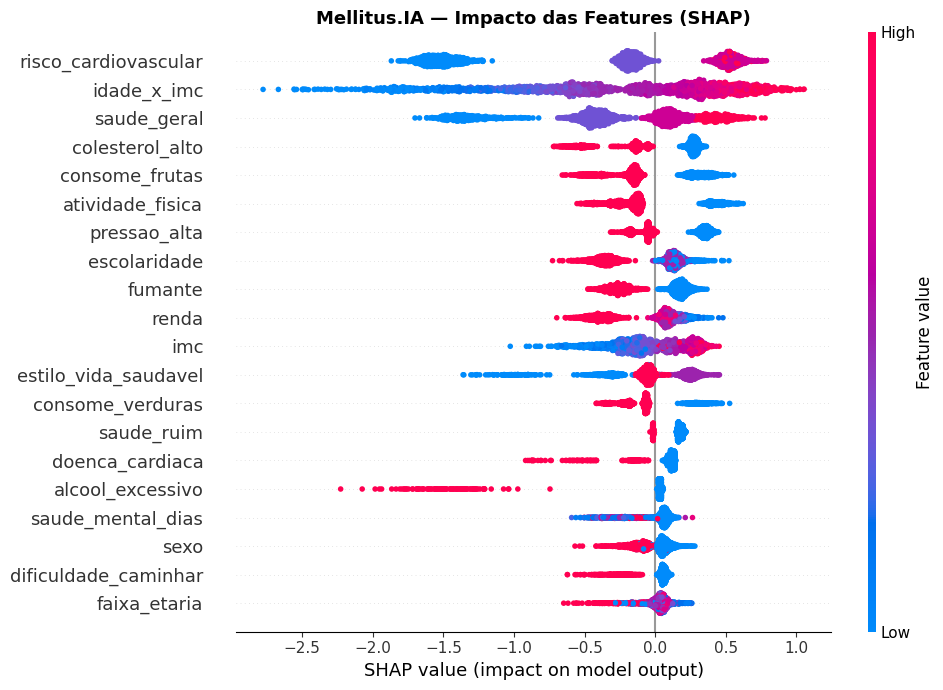

📊 Gráfico SHAP salvo: shap_summary.png


In [13]:
print("Calculando SHAP values (pode levar ~1 minuto)...")

# Pegar o estimador interno do pipeline
estimador = modelo_final.named_steps["model"]
scaler    = modelo_final.named_steps["scaler"]

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_NAMES
)

# Amostrar 2000 registros para o SHAP não demorar demais
X_shap = X_test_scaled.sample(2000, random_state=42)

try:
    explainer   = shap.TreeExplainer(estimador)
    shap_values = explainer.shap_values(X_shap)

    # Para classificadores binários, pegar a classe positiva
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_shap, feature_names=FEATURE_NAMES, show=False, plot_size=(10, 7))
    plt.title("Mellitus.IA — Impacto das Features (SHAP)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📊 Gráfico SHAP salvo: shap_summary.png")
except Exception as e:
    print(f"⚠️  SHAP não disponível para este modelo: {e}")


# ║  CÉLULA 14 — Função de classificação de risco

In [14]:
def classificar_risco(probabilidade: float) -> dict:
    """
    Converte a probabilidade bruta do modelo em classificação de risco
    conforme os critérios do projeto Mellitus.IA.
    """
    pct = round(probabilidade * 100, 1)

    if probabilidade < 0.30:
        return {
            "nivel":      "BAIXO RISCO",
            "porcentagem": pct,
            "cor":        "verde",
            "orientacao": (
                "Seu perfil atual indica baixo risco para diabetes tipo 2. "
                "Mantenha hábitos saudáveis: alimentação equilibrada, "
                "atividade física regular e consultas de rotina anuais."
            ),
        }
    elif probabilidade < 0.60:
        return {
            "nivel":      "RISCO MODERADO",
            "porcentagem": pct,
            "cor":        "amarelo",
            "orientacao": (
                "Seu perfil indica risco moderado. Recomendamos a realização "
                "de exames laboratoriais e acompanhamento com profissional de saúde. "
                "Pequenas mudanças no estilo de vida podem reduzir significativamente esse risco."
            ),
        }
    else:
        return {
            "nivel":      "ALTO RISCO",
            "porcentagem": pct,
            "cor":        "vermelho",
            "orientacao": (
                "Seu perfil indica alto risco para diabetes tipo 2. "
                "Procure encaminhamento urgente a um endocrinologista ou médico especialista. "
                "Exames e intervenção precoce são essenciais para evitar complicações graves."
            ),
        }

# Demonstração com 3 cenários
print("Demonstração da classificação de risco:\n")
for prob in [0.12, 0.44, 0.75]:
    res = classificar_risco(prob)
    print(f"  {prob:.0%} → {res['nivel']} ({res['cor'].upper()})")
    print(f"    {res['orientacao'][:90]}...\n")

Demonstração da classificação de risco:

  12% → BAIXO RISCO (VERDE)
    Seu perfil atual indica baixo risco para diabetes tipo 2. Mantenha hábitos saudáveis: alim...

  44% → RISCO MODERADO (AMARELO)
    Seu perfil indica risco moderado. Recomendamos a realização de exames laboratoriais e acom...

  75% → ALTO RISCO (VERMELHO)
    Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgente a um end...



# ║ CÉLULA 15 — Simulação com pacientes fictícios

In [15]:
pacientes_demo = [
    {
        "nome": "Lucas, 27 anos, ativo e saudável",
        "imc": 22.0, "pressao_alta": 0, "colesterol_alto": 0,
        "atividade_fisica": 1, "saude_geral": 1, "faixa_etaria": 2,
        "doenca_cardiaca": 0, "avc": 0, "fumante": 0,
        "dificuldade_caminhar": 0, "sexo": 1, "saude_fisica_dias": 0,
        "saude_mental_dias": 2, "consome_frutas": 1, "consome_verduras": 1,
        "alcool_excessivo": 0, "escolaridade": 5, "renda": 6,
    },
    {
        "nome": "Ana, 48 anos, sobrepeso e hipertensa",
        "imc": 29.5, "pressao_alta": 1, "colesterol_alto": 1,
        "atividade_fisica": 0, "saude_geral": 3, "faixa_etaria": 7,
        "doenca_cardiaca": 0, "avc": 0, "fumante": 0,
        "dificuldade_caminhar": 0, "sexo": 0, "saude_fisica_dias": 5,
        "saude_mental_dias": 5, "consome_frutas": 1, "consome_verduras": 1,
        "alcool_excessivo": 0, "escolaridade": 4, "renda": 4,
    },
    {
        "nome": "Roberto, 62 anos, obeso + cardiopata + sedentário",
        "imc": 35.8, "pressao_alta": 1, "colesterol_alto": 1,
        "atividade_fisica": 0, "saude_geral": 4, "faixa_etaria": 10,
        "doenca_cardiaca": 1, "avc": 0, "fumante": 1,
        "dificuldade_caminhar": 1, "sexo": 1, "saude_fisica_dias": 15,
        "saude_mental_dias": 10, "consome_frutas": 0, "consome_verduras": 0,
        "alcool_excessivo": 0, "escolaridade": 3, "renda": 2,
    },
]

def _adicionar_features_derivadas(d: dict) -> dict:
    """Replica a engenharia de features do treinamento."""
    d = dict(d)
    d["risco_cardiovascular"]  = d["pressao_alta"] + d["colesterol_alto"] + d["doenca_cardiaca"]
    imc = d["imc"]
    if   imc < 18.5: d["categoria_imc"] = 0
    elif imc < 25.0: d["categoria_imc"] = 1
    elif imc < 30.0: d["categoria_imc"] = 2
    else:            d["categoria_imc"] = 3
    d["estilo_vida_saudavel"] = d["atividade_fisica"] + d["consome_frutas"] + d["consome_verduras"]
    d["idade_x_imc"]          = d["faixa_etaria"] * d["imc"]
    d["saude_ruim"]           = 1 if d["saude_geral"] >= 4 else 0
    return d

print("=" * 65)
print("  SIMULAÇÃO DE USO REAL — Mellitus.IA")
print("=" * 65)
for p in pacientes_demo:
    nome = p.pop("nome")
    p_feat = _adicionar_features_derivadas(p)
    X_demo = pd.DataFrame([p_feat])[FEATURE_NAMES]
    prob = float(modelo_final.predict_proba(X_demo)[0][1])
    res = classificar_risco(prob)
    print(f"\n  Paciente : {nome}")
    print(f"  Resultado: {res['nivel']} — {res['porcentagem']}% de probabilidade")
    print(f"  {res['orientacao'][:100]}...")
print("=" * 65)

  SIMULAÇÃO DE USO REAL — Mellitus.IA

  Paciente : Lucas, 27 anos, ativo e saudável
  Resultado: BAIXO RISCO — 1.9% de probabilidade
  Seu perfil atual indica baixo risco para diabetes tipo 2. Mantenha hábitos saudáveis: alimentação eq...

  Paciente : Ana, 48 anos, sobrepeso e hipertensa
  Resultado: ALTO RISCO — 78.5% de probabilidade
  Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgente a um endocrinologi...

  Paciente : Roberto, 62 anos, obeso + cardiopata + sedentário
  Resultado: ALTO RISCO — 86.3% de probabilidade
  Seu perfil indica alto risco para diabetes tipo 2. Procure encaminhamento urgente a um endocrinologi...


# ║  CÉLULA 16 — Salvar modelo e artefatos

In [18]:
joblib.dump(modelo_final, "mellitus_modelo.pkl")
print("✅ Modelo salvo: mellitus_modelo.pkl")

artefatos = {
    "features":      FEATURE_NAMES,
    "modelo_nome":   melhor_nome,
    "dataset":       "CDC BRFSS Diabetes Health Indicators (UCI id=891)",
    "total_registros": int(len(df)),
    "metricas": {
        "acuracia": round(float(acc), 4),
        "roc_auc":  round(float(roc_auc), 4),
        "f1_score": round(float(f1), 4),
        "recall":   round(float(recall), 4),
        "precisao": round(float(prec), 4),
    },
    "limites_risco": {
        "baixo":    "probabilidade < 30%",
        "moderado": "probabilidade 30% – 60%",
        "alto":     "probabilidade > 60%",
    },
    "mapa_features": {
        "imc":                  "Índice de Massa Corporal",
        "pressao_alta":         "Hipertensão (0=não, 1=sim)",
        "colesterol_alto":      "Colesterol alto (0=não, 1=sim)",
        "atividade_fisica":     "Pratica atividade física (0=não, 1=sim)",
        "saude_geral":          "Saúde geral autorrelatada (1=excelente a 5=ruim)",
        "faixa_etaria":         "Faixa etária (1=18-24 até 13=80+)",
        "doenca_cardiaca":      "Doença cardíaca ou infarto (0=não, 1=sim)",
        "avc":                  "Já teve AVC (0=não, 1=sim)",
        "fumante":              "Fumante (0=não, 1=sim)",
        "dificuldade_caminhar": "Dificuldade de caminhar (0=não, 1=sim)",
        "sexo":                 "Sexo (0=feminino, 1=masculino)",
        "saude_fisica_dias":    "Dias com saúde física ruim nos últimos 30 dias",
        "saude_mental_dias":    "Dias com saúde mental ruim nos últimos 30 dias",
        "consome_frutas":       "Consome frutas diariamente (0=não, 1=sim)",
        "consome_verduras":     "Consome verduras diariamente (0=não, 1=sim)",
        "alcool_excessivo":     "Consumo excessivo de álcool (0=não, 1=sim)",
        "escolaridade":         "Escolaridade (1=nunca estudou a 6=pós-graduação)",
        "renda":                "Faixa de renda (1=menor a 8=maior)",
        "risco_cardiovascular": "Score cardiovascular (soma: hipertensão+colesterol+cardiopatia)",
        "categoria_imc":        "Categoria IMC OMS (0=abaixo peso, 1=normal, 2=sobrepeso, 3=obeso)",
        "estilo_vida_saudavel": "Score estilo de vida (atividade+frutas+verduras, 0-3)",
        "idade_x_imc":          "Interação faixa etária × IMC",
        "saude_ruim":           "Saúde geral ruim (1 se saúde_geral >= 4)",
    }
}

with open("mellitus_artefatos.json", "w", encoding="utf-8") as f:
    json.dump(artefatos, f, ensure_ascii=False, indent=2)
print("✅ Artefatos salvos: mellitus_artefatos.json")

✅ Modelo salvo: mellitus_modelo.pkl
✅ Artefatos salvos: mellitus_artefatos.json


# ║  CÉLULA 17 — Download dos arquivos gerados

In [19]:
from google.colab import files

arquivos = [
    ("mellitus_modelo.pkl",        "Modelo treinado → backend FastAPI"),
    ("mellitus_artefatos.json",    "Metadados, features e métricas → backend FastAPI"),
    ("prevalencia_por_fator.png",  "Gráfico de prevalência por fator de risco"),
    ("imc_e_idade.png",            "Gráfico de IMC e faixa etária"),
    ("avaliacao_modelo.png",       "Curva ROC, matriz de confusão, importância"),
    ("shap_summary.png",           "Explicabilidade SHAP (se gerado)"),
]

print("Iniciando downloads...\n")
for arquivo, descricao in arquivos:
    try:
        files.download(arquivo)
        print(f"  ⬇️  {arquivo:40s} ← {descricao}")
    except Exception:
        print(f"  ⚠️  {arquivo:40s} ← não gerado, pulando")

print("\n✅ Mellitus.IA — Treinamento completo!")

Iniciando downloads...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  mellitus_modelo.pkl                      ← Modelo treinado → backend FastAPI


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  avaliacao_modelo.png                     ← Curva ROC, matriz de confusão, importância


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  shap_summary.png                         ← Explicabilidade SHAP (se gerado)

✅ Mellitus.IA — Treinamento completo!
